In [1]:

import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate

from autotsc import utils

In [2]:
rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect().lazy()
v = rdf.group_by("model").agg(pl.len()).sort("len", descending=True).collect()
for row in v.iter_rows(named=True):
    print(f"{row['model']}: {row['len']}")

/tmp/ipykernel_3589272/2562833565.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect().lazy()


rdst: 640
u-rstsf: 640
rank-mr-hydra: 640
difference-mr-hydra: 640
downsample-mr-hydra: 640
scale-mr-hydra: 640
cumsum-mr-hydra: 640
catch22: 640
stacker-v4-r1: 640
quant: 640
rstsf: 640
polar-angle-mr-hydra: 640
polar-magnitude-mr-hydra: 640
mr-hydra: 640
hivecotev2: 401
drcif: 370
fast-stacker-v4-r1: 73
fast-stacker-v5-r1: 46
stacker-v4-r3: 23
fast-stacker-v5-r3: 4


In [3]:
df = (
    rdf
    .filter(pl.col("model") != "stacker-v4-r3")
    .filter(pl.col("model") != "difference-mr-hydra")
    .filter(pl.col("model") != "scale-mr-hydra")
    .filter(pl.col("model") != "cumsum-mr-hydra")
    .filter(pl.col("model") != "downsample-mr-hydra")
    .filter(pl.col("model") != "rank-mr-hydra")
    .filter(pl.col("model") != "polar-magnitude-mr-hydra")
    .filter(pl.col("model") != "polar-angle-mr-hydra")
    .filter(pl.col("model") != "catch22")
    #.filter(pl.col("model") != "drcif")
    .filter(pl.col("model") != "fast-stacker-v5-r3")

).collect(engine="streaming")
df

dataset,model,run,resampled,test_accuracy
str,str,i64,bool,f64
"""OSULeaf""","""hivecotev2""",100,false,0.96281
"""Trace""","""u-rstsf""",400,false,1.0
"""TwoLeadECG""","""drcif""",500,false,0.982441
"""GesturePebbleZ2""","""stacker-v4-r1""",300,false,0.879747
"""SemgHandMovementCh2""","""mr-hydra""",300,false,0.771111
…,…,…,…,…
"""ScreenType""","""rstsf""",100,false,0.541333
"""ECG200""","""rdst""",300,false,0.9
"""SemgHandGenderCh2""","""stacker-v4-r1""",100,false,0.96


In [4]:
rdf.collect()['model'].unique()

model
str
"""stacker-v4-r3"""
"""fast-stacker-v4-r1"""
"""cumsum-mr-hydra"""
"""rank-mr-hydra"""
"""difference-mr-hydra"""
…
"""rdst"""
"""stacker-v4-r1"""
"""fast-stacker-v5-r3"""


In [5]:
from aeon.visualisation import plot_critical_difference

In [6]:
v = df.pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).drop_nulls()
methods = df["model"].unique().to_list()
v

dataset,hivecotev2,u-rstsf,drcif,stacker-v4-r1,mr-hydra,fast-stacker-v5-r1,quant,rdst,rstsf,fast-stacker-v4-r1
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""DistalPhalanxOutlineCorrect""",0.775362,0.784058,0.807971,0.797101,0.802899,0.804348,0.788406,0.773188,0.791304,0.782609
"""WormsTwoClass""",0.822511,0.85974,0.796537,0.78961,0.787013,0.792208,0.812987,0.761039,0.812987,0.805195
"""TwoPatterns""",1.0,0.992,0.9940625,1.0,1.0,1.0,0.99995,1.0,0.99645,1.0
"""ItalyPowerDemand""",0.969874,0.959184,0.96631,0.965598,0.969485,0.965986,0.965986,0.944995,0.970651,0.965015
"""EthanolLevel""",0.683,0.4584,0.585333,0.6988,0.6344,0.704,0.7028,0.6576,0.5512,0.694
…,…,…,…,…,…,…,…,…,…,…
"""StarLightCurves""",0.982273,0.980282,0.980148,0.982807,0.981666,0.98288,0.979845,0.98237,0.979699,0.983001
"""MiddlePhalanxTW""",0.574675,0.584416,0.551948,0.58961,0.52987,0.571429,0.580519,0.52987,0.574026,0.603896
"""CinCECGTorso""",0.999638,0.947536,0.995833,0.994493,0.973333,0.993478,0.994058,0.991884,0.974638,0.994928


(<Figure size 600x290 with 1 Axes>, <Axes: >)

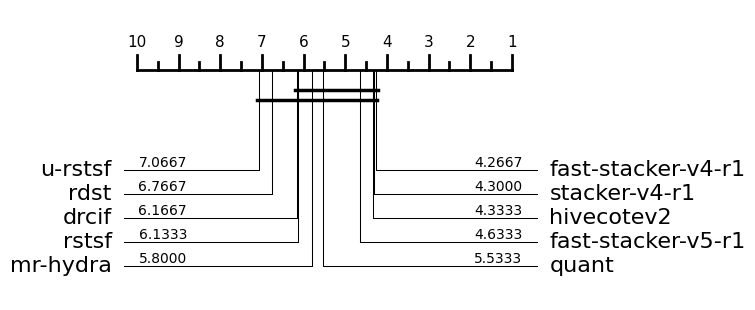

In [7]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [8]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [9]:
joined = v.join(stats, on="dataset").sort("n_train")
joined

dataset,hivecotev2,u-rstsf,drcif,stacker-v4-r1,mr-hydra,fast-stacker-v5-r1,quant,rdst,rstsf,fast-stacker-v4-r1,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""SonyAIBORobotSurface2""",0.921826,0.913536,0.902413,0.935992,0.941658,0.940189,0.848059,0.894229,0.882057,0.925498,27,953,2,65
"""FreezerSmallTrain""",0.998947,0.965263,0.998947,0.998386,0.994316,0.997895,0.998947,0.994877,0.996561,0.998947,28,2850,2,301
"""Beef""",0.844444,0.786667,0.788889,0.773333,0.766667,0.5,0.786667,0.833333,0.793333,0.8,30,30,5,470
"""CinCECGTorso""",0.999638,0.947536,0.995833,0.994493,0.973333,0.993478,0.994058,0.991884,0.974638,0.994928,40,1380,4,1639
"""ItalyPowerDemand""",0.969874,0.959184,0.96631,0.965598,0.969485,0.965986,0.965986,0.944995,0.970651,0.965015,67,1029,2,24
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""MiddlePhalanxTW""",0.574675,0.584416,0.551948,0.58961,0.52987,0.571429,0.580519,0.52987,0.574026,0.603896,399,154,6,80
"""EthanolLevel""",0.683,0.4584,0.585333,0.6988,0.6344,0.704,0.7028,0.6576,0.5512,0.694,504,500,4,1751
"""DistalPhalanxOutlineCorrect""",0.775362,0.784058,0.807971,0.797101,0.802899,0.804348,0.788406,0.773188,0.791304,0.782609,600,276,2,80


10


(<Figure size 600x290 with 1 Axes>, <Axes: >)

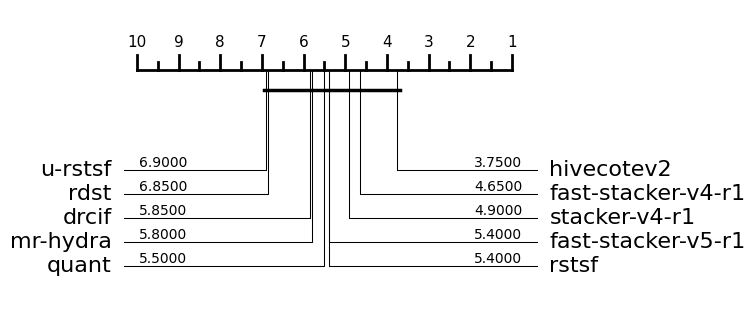

In [10]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

2


(<Figure size 600x290 with 1 Axes>, <Axes: >)

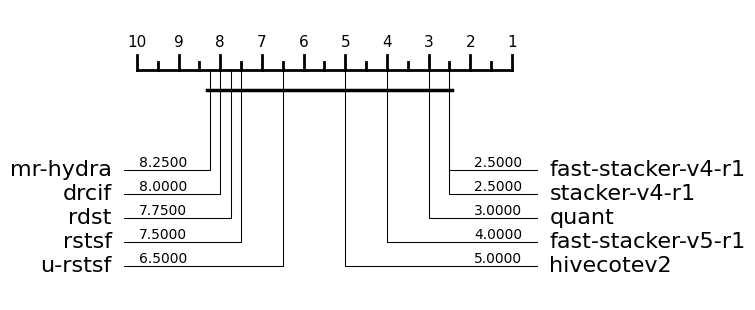

In [11]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

3


(<Figure size 600x290 with 1 Axes>, <Axes: >)

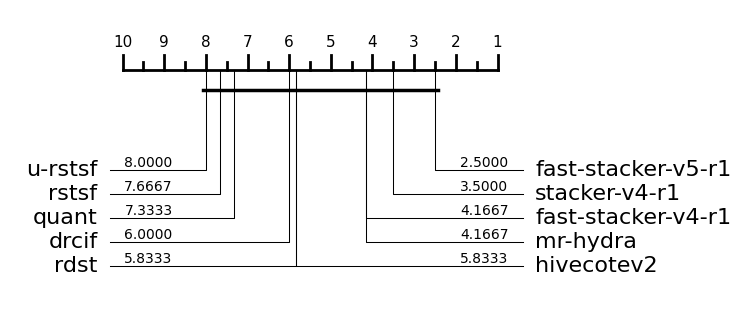

In [12]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [13]:
rdf.collect().pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).sort('downsample-mr-hydra')

dataset,polar-angle-mr-hydra,hivecotev2,downsample-mr-hydra,scale-mr-hydra,polar-magnitude-mr-hydra,catch22,u-rstsf,drcif,stacker-v4-r1,cumsum-mr-hydra,mr-hydra,rank-mr-hydra,fast-stacker-v5-r1,stacker-v4-r3,quant,rdst,rstsf,difference-mr-hydra,fast-stacker-v4-r1,fast-stacker-v5-r3
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Phoneme""",0.288502,0.396449,0.327954,0.349895,0.354008,0.305802,0.38903,0.356672,0.349895,0.269093,0.349895,0.34557,null,null,0.382278,0.337975,0.380907,0.369831,null,null
"""InlineSkate""",0.436727,0.533182,0.464364,0.496727,0.497455,0.434182,0.623636,0.516364,0.586545,0.431273,0.497091,0.469818,0.584545,null,0.586909,0.447273,0.601818,0.475273,0.569091,null
"""ScreenType""",0.488533,0.561778,0.511467,0.529067,0.5392,0.501867,0.5504,0.533333,0.546133,0.48,0.5472,0.495467,null,null,0.5328,0.5216,0.522133,0.5344,0.557333,null
"""MiddlePhalanxOutlineAgeGroup""",0.527273,0.575325,0.515584,0.580519,0.544156,0.6,0.603896,0.574026,0.580519,0.579221,0.576623,0.579221,null,null,0.61039,0.584416,0.597403,0.535065,0.587662,null
"""RefrigerationDevices""",0.589333,0.549333,0.521067,0.528,0.524267,0.507733,0.5824,0.597333,0.577067,0.506133,0.526933,0.5472,0.562667,null,0.581867,0.5568,0.5904,0.538667,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GunPointOldVersusYoung""",0.996825,1.0,1.0,0.996825,1.0,1.0,1.0,1.0,1.0,0.989841,1.0,0.979683,1.0,null,1.0,1.0,1.0,1.0,1.0,null
"""TwoPatterns""",0.99195,1.0,1.0,1.0,0.30035,0.8436,0.992,0.9940625,1.0,0.9977,1.0,0.99975,1.0,1.0,0.99995,1.0,0.99645,0.9932,1.0,null
"""GunPointMaleVersusFemale""",0.996835,1.0,1.0,1.0,1.0,0.990506,1.0,0.999209,1.0,0.996835,1.0,0.982278,1.0,1.0,1.0,1.0,1.0,0.996835,null,null


In [14]:
import ray
ray.shutdown()